In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [2]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
from wordcloud import WordCloud

print("WordCloud imported successfully!")

WordCloud imported successfully!


In [4]:
df = pd.read_excel("dataset.xlsx")
df 


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [5]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1440
Number of columns: 3


In [7]:
#Checking columns names
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [8]:
#Checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [9]:
#Statistical summary 
df.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [10]:
#Rating Statistics
df['rating'].describe()

count    1440.000000
mean        3.173611
std         1.584453
min         1.000000
25%         1.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64

In [11]:
#Checking missing values 
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
title     0
rating    0
body      0
dtype: int64


In [12]:
#Duplicates 
print("Duplicate rows:", df[['title', 'rating', 'body']].duplicated().sum())

Duplicate rows: 0


In [13]:
#Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()

print(rating_counts)

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64


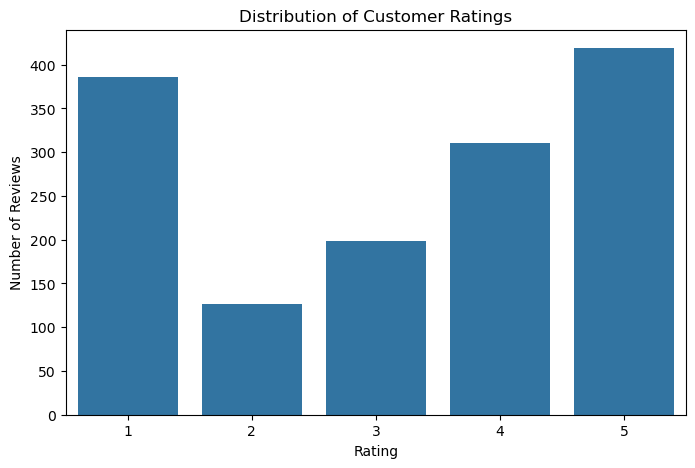

In [14]:
#Rating graph
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='rating')

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
#Review Length
df['review_length'] = df['body'].fillna('').apply(len)

df[['body', 'review_length']].head()

,body,review_length
0,Very disappointed with the overall performance...,59
1,Camera quality is low,21
2,"Got the mobile on the launch date,Battery must...",403
3,1. It doesn't work with 5.0GHz WiFi frequency....,377
4,"Not worth buying....faulty software, poor disp...",179


In [16]:
#Word Count
df['word_count'] = df['body'].fillna('').apply(
    lambda x: len(x.split())
)

df[['body', 'word_count']].head()

,body,word_count
0,Very disappointed with the overall performance...,8
1,Camera quality is low,4
2,"Got the mobile on the launch date,Battery must...",66
3,1. It doesn't work with 5.0GHz WiFi frequency....,67
4,"Not worth buying....faulty software, poor disp...",29


In [17]:
#Review Length Statistics
df[['review_length', 'word_count']].describe()

,review_length,word_count
count,1440.000000,1440.000000
mean,302.109028,52.892361
std,225.733052,39.346259
min,4.000000,1.000000
25%,170.000000,29.000000
50%,246.000000,43.000000
75%,359.000000,63.250000
max,2490.000000,385.000000


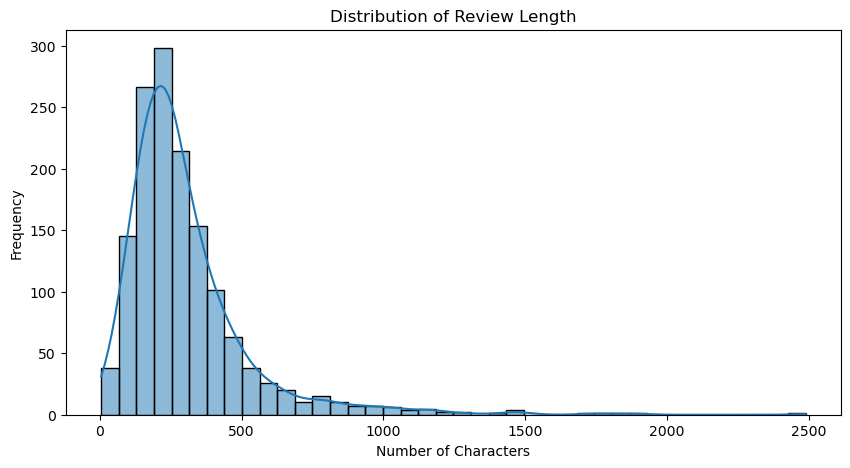

In [18]:
#Review Length Graph
plt.figure(figsize=(10, 5))

sns.histplot(df['review_length'], bins=40, kde=True)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [19]:
#Create Clean Text
df['clean_text'] = df['body'].fillna('').str.lower()

df[['body', 'clean_text']].head()

,body,clean_text
0,Very disappointed with the overall performance...,very disappointed with the overall performance...
1,Camera quality is low,camera quality is low
2,"Got the mobile on the launch date,Battery must...","got the mobile on the launch date,battery must..."
3,1. It doesn't work with 5.0GHz WiFi frequency....,1. it doesn't work with 5.0ghz wifi frequency....
4,"Not worth buying....faulty software, poor disp...","not worth buying....faulty software, poor disp..."


In [20]:
#Remove Punctuation
df['clean_text'] = df['clean_text'].apply(
    lambda x: x.translate(
        str.maketrans('', '', string.punctuation)
    )
)

df['clean_text'].head()

0    very disappointed with the overall performance...
1                                camera quality is low
2    got the mobile on the launch datebattery must ...
3    1 it doesnt work with 50ghz wifi frequency 24g...
4    not worth buyingfaulty software poor display q...
Name: clean_text, dtype: object

In [21]:
#Remove Numbers
df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

df['clean_text'].head()

0    very disappointed with the overall performance...
1                                camera quality is low
2    got the mobile on the launch datebattery must ...
3     it doesnt work with ghz wifi frequency ghz is...
4    not worth buyingfaulty software poor display q...
Name: clean_text, dtype: object

In [22]:
#Remove Extra Spaces
df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

df['clean_text'].head()

0    very disappointed with the overall performance...
1                                camera quality is low
2    got the mobile on the launch datebattery must ...
3    it doesnt work with ghz wifi frequency ghz is ...
4    not worth buyingfaulty software poor display q...
Name: clean_text, dtype: object

In [23]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
#Remove Stopwords
stop_words= set(stopwords.words('english'))

df['tokens'] = df['clean_text'].apply(
    lambda x: [
        word for word in x.split()
        if word not in stop_words
    ]
)

df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,very disappointed with the overall performance...,"[disappointed, overall, performance, samsung]"
1,camera quality is low,"[camera, quality, low]"
2,got the mobile on the launch datebattery must ...,"[got, mobile, launch, datebattery, must, appre..."
3,it doesnt work with ghz wifi frequency ghz is ...,"[doesnt, work, ghz, wifi, frequency, ghz, old,..."
4,not worth buyingfaulty software poor display q...,"[worth, buyingfaulty, software, poor, display,..."


In [25]:
from collections import Counter

In [26]:
#Find the Top 20 Most Frequent Words
all_words = []

for words in df['tokens']:
    all_words.extend(words)

word_frequency = Counter(all_words)

top_words = word_frequency.most_common(20)

print(top_words)

[('phone', 1439), ('good', 1079), ('camera', 846), ('battery', 710), ('samsung', 612), ('quality', 607), ('mobile', 488), ('price', 329), ('also', 301), ('product', 287), ('life', 279), ('like', 276), ('display', 262), ('buy', 248), ('use', 229), ('better', 228), ('dont', 227), ('screen', 225), ('one', 221), ('using', 203)]


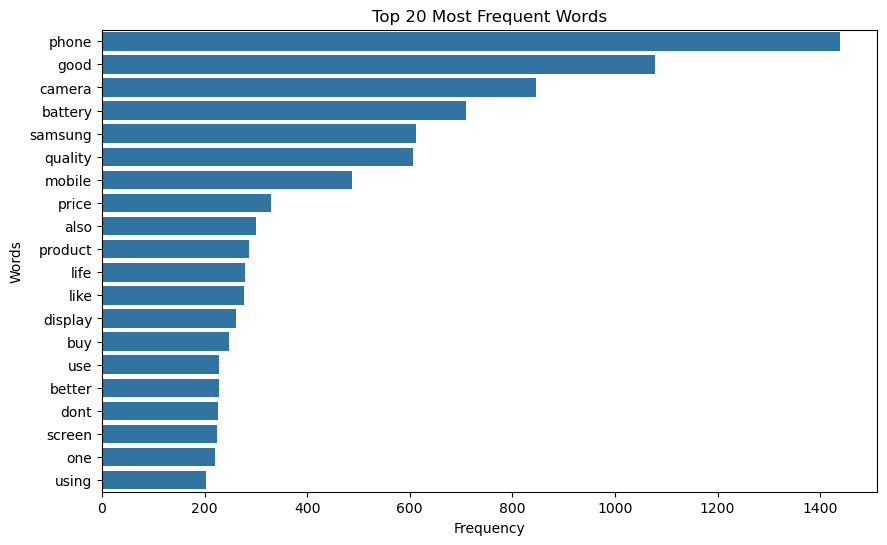

In [27]:
#Visualize top 20 words 
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()


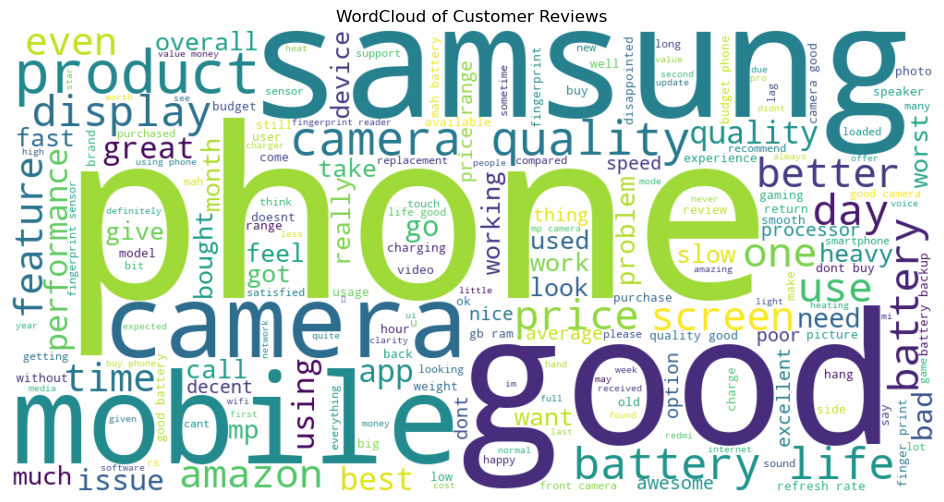

In [28]:
#WordCloud
all_text = ' '.join(all_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("WordCloud of Customer Reviews")

plt.show()

In [29]:
#Create Sentiment Categories
def get_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(get_sentiment)

df[['rating', 'sentiment']].head()

,rating,sentiment
0,1,Negative
1,3,Neutral
2,4,Positive
3,1,Negative
4,1,Negative


In [30]:
# Create Sentiment column

def sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(sentiment)

df[['rating', 'sentiment']].head(10)

,rating,sentiment
0,1,Negative
1,3,Neutral
2,4,Positive
3,1,Negative
4,1,Negative
5,1,Negative
6,1,Negative
7,1,Negative
8,1,Negative
9,1,Negative


In [31]:
#Sentiment Counts
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


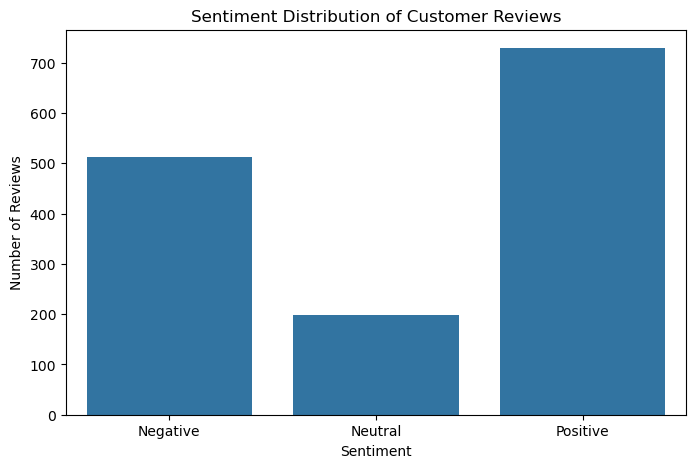

In [32]:
#Sentiment Graph
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='sentiment',
    order=['Negative', 'Neutral', 'Positive']
)

plt.title("Sentiment Distribution of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [33]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df[['title', 'rating', 'body']].duplicated().sum())


Missing Values:
title            0
rating           0
body             0
review_length    0
word_count       0
clean_text       0
tokens           0
sentiment        0
dtype: int64

Duplicate Rows:
0


# **MODEL BUILDING & EVALUATION**

In [34]:
#1-Feature Extraction using TF-IDF

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

TF-IDF Matrix Shape: (1440, 5000)
Target Shape: (1440,)


In [36]:
#2-Train-Test Split
print("TF-IDF Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

TF-IDF Matrix Shape: (1440, 5000)
Target Shape: (1440,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1152
Testing samples: 288


In [38]:
#Model -1 . Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [39]:
#Model 2 — Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [40]:
#Model -3 Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [41]:
#Model -4 K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

print("KNN model trained successfully!")


KNN model trained successfully!


In [42]:
#Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [43]:
#Evaluating all 4 models
def evaluate_model(model_name, y_test, y_pred):
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    
    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))
    
    return accuracy, precision, recall, f1

In [44]:
#Logistic Regression Evaluation
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

Logistic Regression
Accuracy : 0.7674
Precision: 0.7321
Recall   : 0.7674
F1 Score : 0.7151

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.79       102
     Neutral       0.50      0.03      0.05        40
    Positive       0.77      0.95      0.85       146

    accuracy                           0.77       288
   macro avg       0.68      0.59      0.56       288
weighted avg       0.73      0.77      0.72       288



In [45]:
#Decision Tree Evaluation
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)


Decision Tree
Accuracy : 0.6181
Precision: 0.6107
Recall   : 0.6181
F1 Score : 0.6139

Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.68      0.65       102
     Neutral       0.14      0.12      0.13        40
    Positive       0.73      0.71      0.72       146

    accuracy                           0.62       288
   macro avg       0.50      0.50      0.50       288
weighted avg       0.61      0.62      0.61       288



In [46]:
#Random Forest Evaluation
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
Accuracy : 0.7326
Precision: 0.6318
Recall   : 0.7326
F1 Score : 0.6762

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.73      0.92      0.81       146

    accuracy                           0.73       288
   macro avg       0.49      0.56      0.52       288
weighted avg       0.63      0.73      0.68       288



In [47]:
#KNN Evaluation
knn_results = evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    y_pred_knn
)


K-Nearest Neighbors
Accuracy : 0.6944
Precision: 0.6403
Recall   : 0.6944
F1 Score : 0.661

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.74      0.71       102
     Neutral       0.17      0.05      0.08        40
    Positive       0.74      0.84      0.79       146

    accuracy                           0.69       288
   macro avg       0.53      0.54      0.52       288
weighted avg       0.64      0.69      0.66       288



In [48]:
#Model Comparison
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        knn_results[0]
    ],
    'Precision': [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        knn_results[1]
    ],
    'Recall': [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        knn_results[2]
    ],
    'F1 Score': [
        lr_results[3],
        dt_results[3],
        rf_results[3],
        knn_results[3]
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7674,0.7321,0.7674,0.7151
1,Decision Tree,0.6181,0.6107,0.6181,0.6139
2,Random Forest,0.7326,0.6318,0.7326,0.6762
3,KNN,0.6944,0.6403,0.6944,0.6610


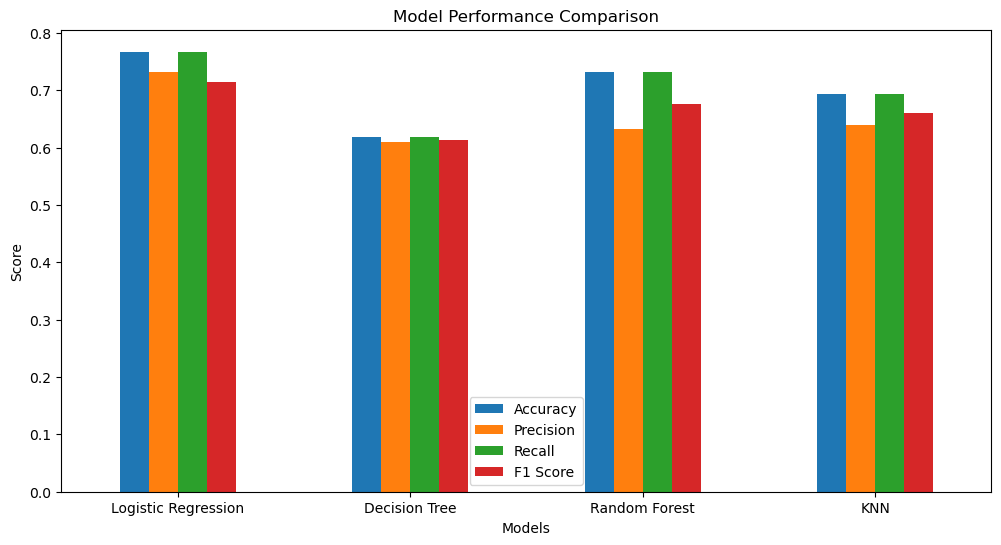

In [49]:
#Performance Comparison Graph
comparison_plot = comparison.set_index('Model')

comparison_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

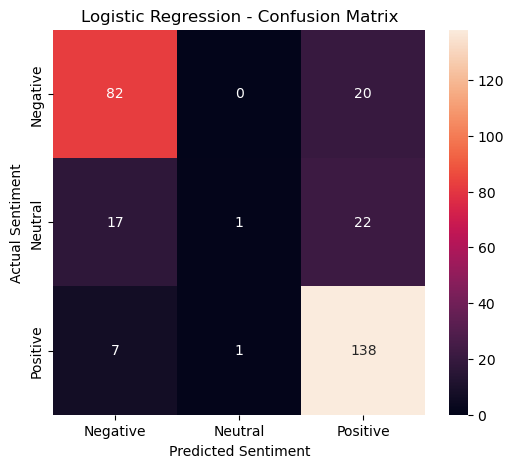

In [50]:
#Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

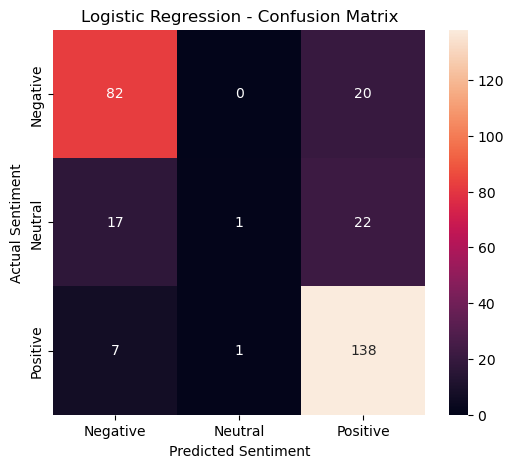

In [51]:
#Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

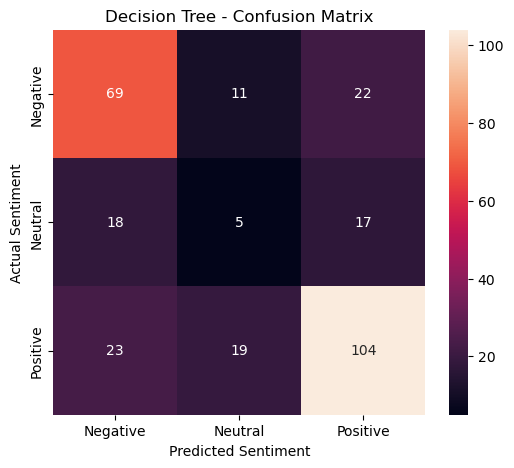

In [52]:
#Decision Tree

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

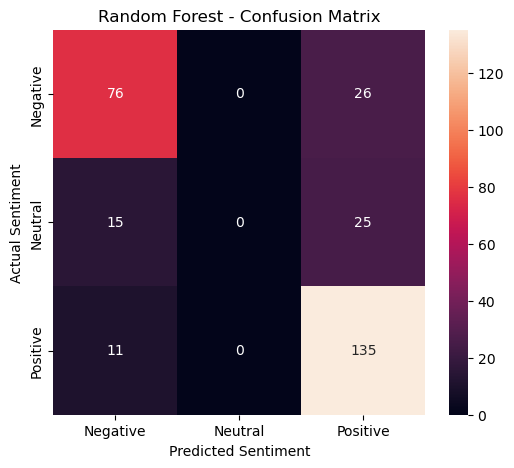

In [53]:
#Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

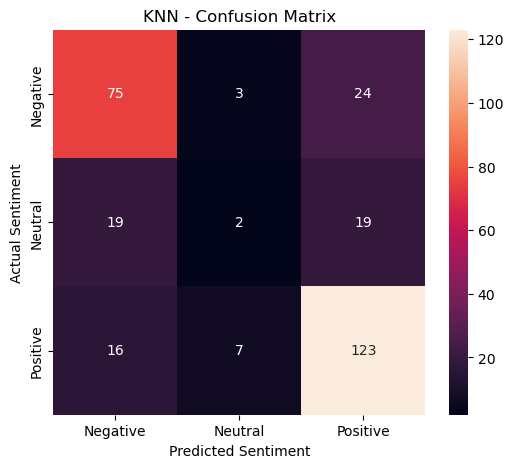

In [54]:
#KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [55]:
#Select the Best Model
best_model = comparison.loc[
    comparison['F1 Score'].idxmax()
]

print("Best Model:", best_model['Model'])
print("Accuracy :", round(best_model['Accuracy'], 4))
print("Precision:", round(best_model['Precision'], 4))
print("Recall   :", round(best_model['Recall'], 4))
print("F1 Score :", round(best_model['F1 Score'], 4))

Best Model: Logistic Regression
Accuracy : 0.7674
Precision: 0.7321
Recall   : 0.7674
F1 Score : 0.7151


In [56]:
#complete comparison table
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7674,0.7321,0.7674,0.7151
1,Decision Tree,0.6181,0.6107,0.6181,0.6139
2,Random Forest,0.7326,0.6318,0.7326,0.6762
3,KNN,0.6944,0.6403,0.6944,0.6610


In [57]:
#Preprocessing function for new reviews
#Applies the SAME cleaning steps used above to create 'clean_text':
#lowercase -> remove punctuation -> remove numbers -> remove extra spaces
#(app.py uses this exact same function)
def preprocess_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#Check: the function must reproduce the training 'clean_text' column exactly
check = df['body'].fillna('').apply(preprocess_text)
print("Preprocessing matches training data:", (check == df['clean_text']).all())

Preprocessing matches training data:

 True


In [58]:
#Testing best model 
new_review = ["This product is excellent and I am very happy with the quality"]

new_review_tfidf = tfidf.transform([preprocess_text(r) for r in new_review])

prediction = lr_model.predict(new_review_tfidf)

print("Review:", new_review[0])
print("Predicted Sentiment:", prediction[0])

Review: This product is excellent and I am very happy with the quality
Predicted Sentiment: Positive


In [59]:
#Negative review 
new_review = ["The product is very bad and I am disappointed"]

new_review_tfidf = tfidf.transform([preprocess_text(r) for r in new_review])

prediction = lr_model.predict(new_review_tfidf)

print("Review:", new_review[0])
print("Predicted Sentiment:", prediction[0])

Review: The product is very bad and I am disappointed
Predicted Sentiment: Negative


In [60]:
#Best model
#Save the model that was actually selected as best (highest F1 Score),
#not a hard-coded one
import joblib

trained_models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'KNN': knn_model
}

final_model = trained_models[best_model['Model']]

joblib.dump(final_model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Saved model:", best_model['Model'])
print("Model and TF-IDF vectorizer saved successfully!")

Saved model: Logistic Regression
Model and TF-IDF vectorizer saved successfully!


In [61]:
 comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7674,0.7321,0.7674,0.7151
1,Decision Tree,0.6181,0.6107,0.6181,0.6139
2,Random Forest,0.7326,0.6318,0.7326,0.6762
3,KNN,0.6944,0.6403,0.6944,0.6610


# **Model Deployment**

In [62]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
Counter                  type                      <class 'collections.Counter'>
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
KNeighborsClassifier     ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
TfidfVectorizer          type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
WordCloud                type                      <class 'wordcloud.wordcloud.WordCloud'>
X                        csr_matrix                  (0, 1214)	0.61407599766<...>, 499)	0.3574225640404643
X_test                   csr_matrix                  (0, 3380)	0

In [63]:
#Reload the saved files and test them (this is exactly what app.py does)
loaded_model = joblib.load("sentiment_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Loaded model:", type(loaded_model).__name__)

sample = "The battery life is amazing and the camera is superb"
print("Review:", sample)
print("Predicted Sentiment:", loaded_model.predict(loaded_tfidf.transform([preprocess_text(sample)]))[0])

Loaded model: LogisticRegression
Review: The battery life is amazing and the camera is superb
Predicted Sentiment: Positive


In [64]:
import os

print(os.path.exists("sentiment_model.pkl"))
print(os.path.exists("tfidf_vectorizer.pkl"))

True
True
